In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

In [5]:
"""
==========================================================================
Vermoeiingsbelasting windgolven - cyclustelling via Rayleigh-verdeling
==========================================================================
Bepaalt het aantal wisselingen (golven) en de bijbehorende golfhoogte-
verdeling over de levensduur van een constructieonderdeel, en berekent
daaruit de vermoeiingsschade (Palmgren-Miner) met een FAT 71 S-N-curve.

Methodiek (per golfveld met een Hm0 en Tm):
  Stap 1  Binnen een golfveld zijn de individuele golfhoogtes Rayleigh
          verdeeld. Per golfhoogte-bin (5 cm) wordt het tijdsaandeel en
          daaruit het aantal golven n bepaald.
  Storm   35 uur totaal met 6 uur piek (volle Hs); de resterende 29 uur
          gelijk verdeeld over lineaire op- en afbouw (14,5 uur elk).
          Elk tijdstap-blok is een eigen golfveld (eigen Hs).
  Stap 2  Aantal stormen per retourklasse over de levensduur.
  Stap 3  Sommeer over alle golfvelden en stormen -> N per golfhoogte.

Periodes:
  Invoer Tp = piekperiode. Voor de cyclustelling telt de gemiddelde
  (zero-crossing) periode Tm.  JONSWAP-benadering:  Tm = Tp / 1.28.

Rayleigh (golfhoogtes):
  Overschrijdingskans:  P(H' > H) = exp(-(H / Hs)^2)
  Kans in bin [H1,H2]:  P = exp(-(H1/Hs)^2) - exp(-(H2/Hs)^2)
  Golven per uur:       N_uur = 3600 / Tm
==========================================================================
"""



# ==========================================================================
# 1) INVOERPARAMETERS
# ==========================================================================

# --- Levensduur & periode-conversie -------------------------------------
LIFETIME_YEARS = 100.0    # ontwerplevensduur [jaar]
TP_TO_TM       = 1.28     # Tm = Tp / 1.28 (JONSWAP zero-crossing benadering)
n_sluitingen = 330

# --- Stormklassen (uit Bijlage A/B, Hydra-NL, etc.) ---------------------
# n_storms = aantal stormen van deze klasse over de HELE levensduur.
storm_classes = [
    # label                Hs [m]   Tp [s]   n_storms over levensduur
    {"label": "1/1 per jaar",      "Hs": 1.33, "Tp": 8.15,  "n_storms": np.min([1.0 * n_sluitingen, LIFETIME_YEARS])},
    {"label": "1/10 per jaar",     "Hs": 1.72, "Tp": 8.65,  "n_storms": np.min([0.1 * n_sluitingen, LIFETIME_YEARS])},
    {"label": "1/100 per jaar",    "Hs": 2.19, "Tp": 10.11, "n_storms": np.min([0.01 * n_sluitingen, LIFETIME_YEARS])},
    {"label": "1/1.000 per jaar",  "Hs": 2.64, "Tp": 11.01, "n_storms": np.min([0.001 * n_sluitingen, LIFETIME_YEARS])}, 
    {"label": "1/10.000 per jaar", "Hs": 3.13, "Tp": 10.91, "n_storms": np.min([0.0001 * n_sluitingen, LIFETIME_YEARS])}, 
    {"label": "1/100.000 per jaar","Hs": 3.65, "Tp": 12.85, "n_storms": np.min([0.00001 * n_sluitingen, LIFETIME_YEARS])}, 
]

# --- Golfhoogte-bins: 0 t/m 6,05 m in stappen van 5 cm ------------------
DH           = 0.05                              # binbreedte [m]
H_MIN, H_MAX = 0.0, 6.05                         # [m]
centers      = np.arange(H_MIN, H_MAX + DH/2, DH)  # bin-middens [m]
edges_lo     = np.clip(centers - DH/2, 0.0, None)  # ondergrens per bin [m] (geen negatieve H)
edges_hi     = centers + DH/2                    # bovengrens per bin [m]

# --- Stormprofiel: 35 u totaal, 6 u piek, 2x 14,5 u lineair op-/afbouw ---
STORM_DURATION_H = 35.0                          # totale stormduur [uur]
PEAK_H           = 6.0                           # duur volle piek [uur]
RAMP_H           = (STORM_DURATION_H - PEAK_H) / 2.0   # op-/afbouw = 14,5 uur
DT               = 0.5                           # tijdstap [uur] (deelt 14,5 netjes)

# --- FAT 71 S-N-curve (NEN-EN 1993-1-9) ---------------------------------
FAT_CLASS = 71.0          # Delta sigma_C [MPa]
N_C       = 2.0e6         # referentieaantal cycli
N_D       = 5.0e6         # constante-amplitudevermoeiingsgrens
N_L       = 1.0e8         # afkapgrens
M1, M2    = 3.0, 5.0      # hellingen van de bilineaire curve

# --- Spanningsrange per meter golfhoogte ---------------------------------
Hs_design = 3.65     # [m]  ontwerp-Hs waarvoor F_wave/M_wave 
F_wave    = 1.65     # [MN/m] resultante golfkracht bij Hs_design 
x1        = 77     # [m]  afstand tot eerste steunpunt (vakwerkarm)
Wz        = 19.02     # [m^3] weerstandsmoment retaining wall

# Globaal buigend moment bij het steunpunt (overhangend-balkmodel),
M_global_ref = 0.5 * F_wave * x1**2      # [MNm], TOTAAL (niet per m)

# Spanning bij de ontwerpconditie
dSigma_ref = M_global_ref / Wz            # [MPa]

# Lineaire spanningsgradiënt per meter Hs
SIGMA_PER_M = dSigma_ref / Hs_design       # [MPa/m]


# ==========================================================================
# 2) HULPFUNCTIES
# ==========================================================================
def rayleigh_prob_in_bins(Hs, lo, hi):
    H_rms = Hs / np.sqrt(2.0)
    P = np.exp(-(lo / H_rms) ** 2) - np.exp(-(hi / H_rms) ** 2)
    return np.clip(P, 0.0, None)


def storm_Hs_profile(Hs_peak):
    t_edges = np.arange(0.0, STORM_DURATION_H + DT/2, DT)
    t_mid   = (t_edges[:-1] + t_edges[1:]) / 2.0   # midden van elk blok [uur]

    t_peak_start = RAMP_H              # 14,5 u
    t_peak_end   = RAMP_H + PEAK_H     # 20,5 u

    Hs_blok = np.empty_like(t_mid)
    for i, t in enumerate(t_mid):
        if t < t_peak_start:                              # lineaire opbouw
            Hs_blok[i] = Hs_peak * (t / RAMP_H)
        elif t <= t_peak_end:                             # piek
            Hs_blok[i] = Hs_peak
        else:                                             # lineaire afbouw
            Hs_blok[i] = Hs_peak * (1.0 - (t - t_peak_end) / RAMP_H)

    return Hs_blok, np.full_like(t_mid, DT)


def allowable_cycles_fat71(delta_sigma):
    delta_sigma = np.asarray(delta_sigma, dtype=float)
    N_allowable = np.full_like(delta_sigma, np.inf)

    mask_m3 = delta_sigma >= delta_sigma_D
    N_allowable[mask_m3] = N_C * (FAT_CLASS / delta_sigma[mask_m3]) ** M1

    mask_m5 = (delta_sigma > delta_sigma_L) & (delta_sigma < delta_sigma_D)
    N_allowable[mask_m5] = N_D * (delta_sigma_D / delta_sigma[mask_m5]) ** M2

    return N_allowable


# Spanningsniveaus bij knikpunt (D) en afkapgrens (L)
delta_sigma_D = FAT_CLASS   * (N_C / N_D) ** (1.0 / M1)
delta_sigma_L = delta_sigma_D * (N_D / N_L) ** (1.0 / M2)


# ==========================================================================
# 3) CYCLUSTELLING
# ==========================================================================
total_cycles  = np.zeros_like(centers)   # N per golfhoogte-bin over levensduur
overview_rows = []                        # invoer + afgeleide waarden per klasse

for storm in storm_classes:
    Hs_peak, Tp, n_storms = storm["Hs"], storm["Tp"], storm["n_storms"]
    Tm         = Tp / TP_TO_TM            # piek -> gemiddelde periode [s]
    N_per_hour = 3600.0 / Tm             # aantal golven per uur [-]

    overview_rows.append({
        "Klasse":    storm["label"],
        "Hs [m]":    Hs_peak,
        "Tp [s]":    Tp,
        "Tm [s]":    round(Tm, 2),
        "n_stormen": n_storms,
    })

    # Per tijdstap-blok = 1 golfveld met eigen Hs
    Hs_blocks, hrs_blocks = storm_Hs_profile(Hs_peak)
    cycles_per_storm = np.zeros_like(centers)
    for Hs_b, hrs_b in zip(Hs_blocks, hrs_blocks):
        if Hs_b <= 0:
            continue
        N_block = N_per_hour * hrs_b                          # golven in dit blok
        cycles_per_storm += rayleigh_prob_in_bins(Hs_b, edges_lo, edges_hi) * N_block

    total_cycles += cycles_per_storm * n_storms           

df_overview = pd.DataFrame(overview_rows)
df_cycles = pd.DataFrame({
    "H [m]":       np.round(centers, 3),
    "N_cycli [-]": np.round(total_cycles, 0),
})


# ==========================================================================
# 4) VERMOEIINGSSCHADE (Palmgren-Miner met FAT 71)
# ==========================================================================
# Spanningsrange en toelaatbare cycli per golfhoogteklasse
delta_sigma_bins = SIGMA_PER_M * centers
N_allowable      = allowable_cycles_fat71(delta_sigma_bins)

# Miner-schade: alleen delen waar N eindig en > 0 is; overige bins -> 0
valid = np.isfinite(N_allowable) & (N_allowable > 0.0)
damage_bins = np.divide(
    total_cycles, N_allowable,
    out=np.zeros_like(total_cycles, dtype=float),
    where=valid,
)
damage_bins = np.nan_to_num(damage_bins, posinf=0.0, neginf=0.0, nan=0.0)

# Totale schade en geschatte vermoeiingslevensduur
D_total = damage_bins.sum()
fatigue_life_years = LIFETIME_YEARS / D_total if D_total > 0 else np.inf

df_fatigue = pd.DataFrame({
    "H [m]":               centers,
    "n_i [-]":             total_cycles,
    "Delta_sigma_i [MPa]": delta_sigma_bins,
    "N_i [-]":             N_allowable,
    "D_i [-]":             damage_bins,
})


# ==========================================================================
# 5) UITVOER
# ==========================================================================
print(f"Levensduur                : {LIFETIME_YEARS:.0f} jaar")
print(f"Stormduur                 : {STORM_DURATION_H:.0f} uur "
      f"({PEAK_H:.0f} u piek, 2x {RAMP_H:.1f} u op-/afbouw)")
print(f"Tp -> Tm factor           : / {TP_TO_TM}")
print(f"Totaal aantal golfcycli   : {total_cycles.sum():.3e}\n")

print("Ingevoerde stormklassen (invoer + afgeleide Tm):")
print(df_overview.to_string(index=False))
print()

print("Cyclustelling per golfhoogte over de levensduur:")
print(df_cycles.to_string(index=False))
print()

print(f"FAT-klasse                       : FAT {FAT_CLASS:.0f}")
print(f"Delta sigma_C bij 2E6 cycli      : {FAT_CLASS:.2f} MPa")
print(f"Delta sigma_D bij 5E6 cycli      : {delta_sigma_D:.2f} MPa")
print(f"Delta sigma_L bij 1E8 cycli      : {delta_sigma_L:.2f} MPa")
print(f"Totaal aantal golfcycli          : {total_cycles.sum():.3e}")
print(f"Beschouwde periode               : {LIFETIME_YEARS:.1f} jaar")
print(f"Totale Miner-schade              : {D_total:.4f}")
if np.isfinite(fatigue_life_years):
    print(f"Geschatte vermoeiingslevensduur  : {fatigue_life_years:.1f} jaar")
else:
    print("Geschatte vermoeiingslevensduur  : oneindig volgens afkapgrens")
print()

print(df_fatigue.to_string(index=False))


Levensduur                : 100 jaar
Stormduur                 : 35 uur (6 u piek, 2x 14.5 u op-/afbouw)
Tp -> Tm factor           : / 1.28
Totaal aantal golfcycli   : 2.652e+06

Ingevoerde stormklassen (invoer + afgeleide Tm):
            Klasse  Hs [m]  Tp [s]  Tm [s]  n_stormen
      1/1 per jaar    1.33    8.15    6.37   100.0000
     1/10 per jaar    1.72    8.65    6.76    33.0000
    1/100 per jaar    2.19   10.11    7.90     3.3000
  1/1.000 per jaar    2.64   11.01    8.60     0.3300
 1/10.000 per jaar    3.13   10.91    8.52     0.0330
1/100.000 per jaar    3.65   12.85   10.04     0.0033

Cyclustelling per golfhoogte over de levensduur:
 H [m]  N_cycli [-]
  0.00      99624.0
  0.05     181806.0
  0.10     177044.0
  0.15     168072.0
  0.20     159428.0
  0.25     150859.0
  0.30     142402.0
  0.35     134079.0
  0.40     125910.0
  0.45     117919.0
  0.50     110126.0
  0.55     102551.0
  0.60      95215.0
  0.65      88134.0
  0.70      81327.0
  0.75      74806.0
  0.

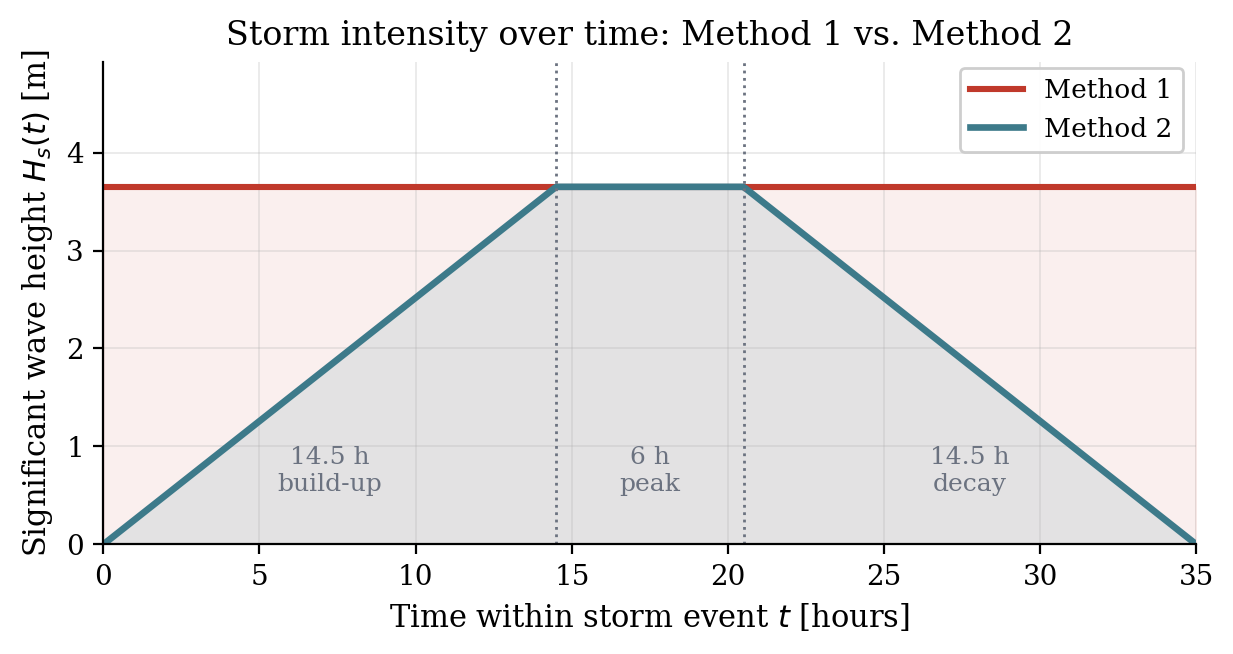

In [6]:
"""
Figure: Storm intensity over time -- Method 1 (constant Hs) vs.
Method 2 (realistic build-up / peak / decay profile).

"""

# ----------------------------------------------------------------------
# Global plot style (consistent, thesis-ready)
# ----------------------------------------------------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 200,
})

# Colors
RED = "#C0392B"
TEAL_DARK = "#3D7A8A"
TEAL = "#61A4B4"
GRAY = "#6B7280"

OUT_DIR = "."  # change to your desired output folder


def fig_storm_profiles():
    # --- Storm timing parameters (Section: Method 2) --------------------
    t_ramp, t_peak = 14.5, 6.0     # [hours] build-up/decay duration, peak duration
    T = 35.0                       # [hours] total storm duration

    Hs_peak = 3.65                # [m]

    t = np.linspace(0, T, 500)

    # Method 2: build-up -> peak -> decay (piecewise linear/constant profile)
    Hs_m2 = np.piecewise(
        t,
        [t < t_ramp, (t >= t_ramp) & (t <= t_ramp + t_peak), t > t_ramp + t_peak],
        [
            lambda t: Hs_peak * t / t_ramp,
            lambda t: Hs_peak,
            lambda t: Hs_peak * (1 - (t - (t_ramp + t_peak)) / t_ramp),
        ],
    )

    # Method 1: constant Hs held for the entire 35-hour storm ("Houtrib" approach)
    Hs_m1 = np.full_like(t, Hs_peak)

    # --- Plot -------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6.3, 3.4))

    ax.plot(t, Hs_m1, color=RED, lw=2.2, label="Method 1")
    ax.plot(t, Hs_m2, color=TEAL_DARK, lw=2.4, label="Method 2")

    ax.fill_between(t, 0, Hs_m2, color=TEAL, alpha=0.15)
    ax.fill_between(t, 0, Hs_m1, color=RED, alpha=0.08)

    # Vertical guide lines marking the phase transitions
    ax.axvline(t_ramp, color=GRAY, ls=":", lw=1)
    ax.axvline(t_ramp + t_peak, color=GRAY, ls=":", lw=1)

    # Phase labels
    ax.annotate("14.5 h\nbuild-up", xy=(t_ramp / 2, 0.55), ha="center", fontsize=9, color=GRAY)
    ax.annotate("6 h\npeak", xy=(t_ramp + t_peak / 2, 0.55), ha="center", fontsize=9, color=GRAY)
    ax.annotate("14.5 h\ndecay", xy=(t_ramp + t_peak + t_ramp / 2, 0.55), ha="center", fontsize=9, color=GRAY)

    ax.set_xlabel("Time within storm event $t$ [hours]")
    ax.set_ylabel("Significant wave height $H_s(t)$ [m]")
    ax.set_xlim(0, T)
    ax.set_ylim(0, Hs_peak * 1.35)
    ax.set_title("Storm intensity over time: Method 1 vs. Method 2")
    ax.legend(loc="right", framealpha=0.95, ncol=1, bbox_to_anchor=(1.0, 0.9))

    fig.tight_layout()
    fig.savefig(f"{OUT_DIR}/fig_storm_profiles.pdf", bbox_inches="tight")

plt.show(fig_storm_profiles())
